# 텍스트마이닝 응용(문서군집, 주제분석)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Machine Learning/1.텍스트 마이닝

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Machine Learning/1.텍스트 마이닝


In [3]:
# Mecab 설치하기
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
!bash ./Mecab-ko-for-Google-Colab/install_mecab-ko_on_colab_light_220429.sh

fatal: destination path 'Mecab-ko-for-Google-Colab' already exists and is not an empty directory.
Installing konlpy.....
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 63.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 34.0 MB/s eta 0:00:00
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-02-24 05:16:39--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.24, 104.192.142.26, 104.192.142.25, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.24|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-02-24 05:16:39 ERROR 404: Not Found.

Done
Unpacking mecab-0.996-ko-0.9.2.tar.gz.......
Done
Change Directory to mecab-0.996-ko-0.9.2.......
./Mecab-ko-for-Google-Colab/install_mecab-ko_on_colab_light_220429.sh: line 23: cd: mecab-0.996-ko-0.9

In [8]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       985Mi       8.0Gi       3.0Mi       3.7Gi        11Gi
Swap:             0B          0B          0B


In [10]:
!cat /proc/meminfo

MemTotal:       13286964 kB
MemFree:         8364032 kB
MemAvailable:   11963228 kB
Buffers:          240948 kB
Cached:          3299120 kB
SwapCached:            0 kB
Active:           964524 kB
Inactive:        3431088 kB
Active(anon):       2620 kB
Inactive(anon):   856152 kB
Active(file):     961904 kB
Inactive(file):  2574936 kB
Unevictable:          20 kB
Mlocked:              20 kB
SwapTotal:             0 kB
SwapFree:              0 kB
Dirty:              3128 kB
Writeback:             0 kB
AnonPages:        822968 kB
Mapped:           475580 kB
Shmem:              3216 kB
KReclaimable:     388000 kB
Slab:             446280 kB
SReclaimable:     388000 kB
SUnreclaim:        58280 kB
KernelStack:        6448 kB
PageTables:         9460 kB
SecPageTables:         0 kB
NFS_Unstable:          0 kB
Bounce:                0 kB
WritebackTmp:          0 kB
CommitLimit:     6643480 kB
Committed_AS:    4000880 kB
VmallocTotal:   34359738367 kB
VmallocUsed:       12936 kB
VmallocChunk:    

In [7]:
#### 압축파일 풀기 unzip()
!unzip './데이터/TS_01. KAKAO.zip' -d './kakao'

Archive:  ./데이터/TS_01. KAKAO.zip
  inflating: ./kakao/KAKAO_1000_01.txt  
  inflating: ./kakao/KAKAO_1000_02.txt  
  inflating: ./kakao/KAKAO_1000_03.txt  
  inflating: ./kakao/KAKAO_1000_04.txt  
  inflating: ./kakao/KAKAO_1000_05.txt  
  inflating: ./kakao/KAKAO_1000_06.txt  
  inflating: ./kakao/KAKAO_1000_07.txt  
  inflating: ./kakao/KAKAO_1000_08.txt  
  inflating: ./kakao/KAKAO_1000_09.txt  
  inflating: ./kakao/KAKAO_1000_10.txt  
  inflating: ./kakao/KAKAO_1000_11.txt  
  inflating: ./kakao/KAKAO_1000_12.txt  
  inflating: ./kakao/KAKAO_1000_13.txt  
  inflating: ./kakao/KAKAO_1000_14.txt  
  inflating: ./kakao/KAKAO_1000_15.txt  
  inflating: ./kakao/KAKAO_1000_16.txt  
  inflating: ./kakao/KAKAO_1000_17.txt  
  inflating: ./kakao/KAKAO_1000_18.txt  
  inflating: ./kakao/KAKAO_1000_19.txt  
  inflating: ./kakao/KAKAO_1000_20.txt  
  inflating: ./kakao/KAKAO_1001_01.txt  
  inflating: ./kakao/KAKAO_1001_02.txt  
  inflating: ./kakao/KAKAO_1001_03.txt  
  inflating: ./kakao/KAK

In [17]:
# 파일관리시스템
import os
from tqdm import tqdm
import pandas as pd

In [13]:
# 파일 이름 가져오기
file_names = os.listdir('./kakao/')

In [14]:
len(file_names)

36000

In [15]:
file_names[0]

'KAKAO_1000_01.txt'

In [19]:
# 파일오픈 -> 텍스트(txt) 데이터 읽기 -> 전체리스트에 추가
total =[]

for fn in tqdm(file_names):
    with open(os.path.join('./kakao/',fn),'r') as f:  # 경로함수 사용하여 
        content = f.read()
        total.append(content)

100%|██████████| 36000/36000 [01:48<00:00, 332.50it/s]


- DataFrame으로 만들기

In [20]:
kakao_df = pd.DataFrame(total, columns = ['원본'])

In [22]:
kakao_df.head()

,원본
0,1 : 애덜앙 나 너무 배불러서 배 아파\n2 : 배 아프면 약국 가서 소화제라도 ...
1,1 : 아 얘들아 나 집들이 할 테니까 너네가 음식 사와라\n2 : 집들이 지금 하...
2,1 : 응원은 돈으로 받아.\n1 : 아 그리고 전세 집인데 투룸이어야 하고 교통편...
3,1 : 그냥 차 주는 회사 취업할게 내가. 면허는 누가 따줄래?\n2 : 차를 주는...
4,1 : 군인들은 산재 처리 되나?\n1 : 엄청 많이 다치잖아\n2 : 군인들은 나...


In [24]:
kakao_df.iloc[0]

,0
원본,1 : 애덜앙 나 너무 배불러서 배 아파\n2 : 배 아프면 약국 가서 소화제라도 ...


### 데이터 전처리
- 정규표현식을 통해 간단하게 전처리
- 화자를 구분하는 번호와 줄바꿈 문자 (\n) 제거
- mecab을 활용하여 형태소 필터링 (명사 추출)

In [26]:
import re

In [28]:
# 화자를 구분하는 번호 제거
p1 = re.compile("[0-9] : ")
temp = kakao_df['원본'].apply(lambda x: re.sub(p1, ' ', x))

In [29]:
temp

,원본
0,애덜앙 나 너무 배불러서 배 아파\n 배 아프면 약국 가서 소화제라도 마시는 거 ...
1,아 얘들아 나 집들이 할 테니까 너네가 음식 사와라\n 집들이 지금 하고 있는 거...
2,응원은 돈으로 받아.\n 아 그리고 전세 집인데 투룸이어야 하고 교통편이 좋아야 ...
3,그냥 차 주는 회사 취업할게 내가. 면허는 누가 따줄래?\n 차를 주는 회사가 아...
4,군인들은 산재 처리 되나?\n 엄청 많이 다치잖아\n 군인들은 나라사랑 카드 발급...
...,...
35995,나 머리 할까?\n 뭔가 머리에 변화를 주고 싶어\n 잉? 갑자기?\n 하고 싶은...
35996,너 사랑니 뽑았어?\n 안 그래도 치과 가야 하는데 귀찮아\n 사랑니 진짜 너무 ...
35997,너가 저번 주에 택배 보냈었잖아\n 응응 그랬지~ 왜에?\n 추석 기간이라 밀렸을...
35998,요새 확실히 TV 안 보는 것 같아\n 왱? 근데 나도 그렇긴 해\n 그치? 왓챠...


In [33]:
# \n (개행)문자 제거
p2 = re.compile("\n")
kakao_df['preprocess text'] = temp.apply(lambda x: re.sub(p2," ", x))

In [34]:
kakao_df

,원본,preprocess text
0,1 : 애덜앙 나 너무 배불러서 배 아파\n2 : 배 아프면 약국 가서 소화제라도 ...,애덜앙 나 너무 배불러서 배 아파 배 아프면 약국 가서 소화제라도 마시는 거 어...
1,1 : 아 얘들아 나 집들이 할 테니까 너네가 음식 사와라\n2 : 집들이 지금 하...,아 얘들아 나 집들이 할 테니까 너네가 음식 사와라 집들이 지금 하고 있는 거 ...
2,1 : 응원은 돈으로 받아.\n1 : 아 그리고 전세 집인데 투룸이어야 하고 교통편...,응원은 돈으로 받아. 아 그리고 전세 집인데 투룸이어야 하고 교통편이 좋아야 하...
3,1 : 그냥 차 주는 회사 취업할게 내가. 면허는 누가 따줄래?\n2 : 차를 주는...,그냥 차 주는 회사 취업할게 내가. 면허는 누가 따줄래? 차를 주는 회사가 아니...
4,1 : 군인들은 산재 처리 되나?\n1 : 엄청 많이 다치잖아\n2 : 군인들은 나...,군인들은 산재 처리 되나? 엄청 많이 다치잖아 군인들은 나라사랑 카드 발급 받...
...,...,...
35995,1 : 나 머리 할까?\n1 : 뭔가 머리에 변화를 주고 싶어\n2 : 잉? 갑자기...,나 머리 할까? 뭔가 머리에 변화를 주고 싶어 잉? 갑자기? 하고 싶은 머리...
35996,1 : 너 사랑니 뽑았어?\n2 : 안 그래도 치과 가야 하는데 귀찮아\n1 : 사...,너 사랑니 뽑았어? 안 그래도 치과 가야 하는데 귀찮아 사랑니 진짜 너무 싫어...
35997,1 : 너가 저번 주에 택배 보냈었잖아\n2 : 응응 그랬지~ 왜에?\n1 : 추석...,너가 저번 주에 택배 보냈었잖아 응응 그랬지~ 왜에? 추석 기간이라 밀렸을 것...
35998,1 : 요새 확실히 TV 안 보는 것 같아\n2 : 왱? 근데 나도 그렇긴 해\n1...,요새 확실히 TV 안 보는 것 같아 왱? 근데 나도 그렇긴 해 그치? 왓챠 있...


In [36]:
from konlpy.tag import Mecab
mecab = Mecab()

In [37]:
kakao_df['형태소']  = kakao_df['preprocess text'].apply(lambda x: mecab.pos(x))

- 형태소 분석기 사용법
    - mecab.morphs() : 출력결과 형태소 토큰 (형태소의 품사를 알 필요가 없을때)
    - mecab.pos() : 출력결과 (형태소, 품사) 튜플형태로 반환 (품사를 )

In [38]:
kakao_df

,원본,preprocess text,형태소
0,1 : 애덜앙 나 너무 배불러서 배 아파\n2 : 배 아프면 약국 가서 소화제라도 ...,애덜앙 나 너무 배불러서 배 아파 배 아프면 약국 가서 소화제라도 마시는 거 어...,"[(애, NNG), (덜, MAG), (앙, IC), (나, NP), (너무, MA..."
1,1 : 아 얘들아 나 집들이 할 테니까 너네가 음식 사와라\n2 : 집들이 지금 하...,아 얘들아 나 집들이 할 테니까 너네가 음식 사와라 집들이 지금 하고 있는 거 ...,"[(아, IC), (얘, NP), (들, XSN), (아, JKV), (나, NP)..."
2,1 : 응원은 돈으로 받아.\n1 : 아 그리고 전세 집인데 투룸이어야 하고 교통편...,응원은 돈으로 받아. 아 그리고 전세 집인데 투룸이어야 하고 교통편이 좋아야 하...,"[(응원, NNG), (은, JX), (돈, NNG), (으로, JKB), (받, ..."
3,1 : 그냥 차 주는 회사 취업할게 내가. 면허는 누가 따줄래?\n2 : 차를 주는...,그냥 차 주는 회사 취업할게 내가. 면허는 누가 따줄래? 차를 주는 회사가 아니...,"[(그냥, MAG), (차, VV+EC), (주, VX), (는, ETM), (회사..."
4,1 : 군인들은 산재 처리 되나?\n1 : 엄청 많이 다치잖아\n2 : 군인들은 나...,군인들은 산재 처리 되나? 엄청 많이 다치잖아 군인들은 나라사랑 카드 발급 받...,"[(군인, NNG), (들, XSN), (은, JX), (산재, NNG), (처리,..."
...,...,...,...
35995,1 : 나 머리 할까?\n1 : 뭔가 머리에 변화를 주고 싶어\n2 : 잉? 갑자기...,나 머리 할까? 뭔가 머리에 변화를 주고 싶어 잉? 갑자기? 하고 싶은 머리...,"[(나, NP), (머리, NNG), (할까, XSV+EF), (?, SF), (뭔..."
35996,1 : 너 사랑니 뽑았어?\n2 : 안 그래도 치과 가야 하는데 귀찮아\n1 : 사...,너 사랑니 뽑았어? 안 그래도 치과 가야 하는데 귀찮아 사랑니 진짜 너무 싫어...,"[(너, NP), (사랑니, NNG), (뽑, VV), (았, EP), (어, EF..."
35997,1 : 너가 저번 주에 택배 보냈었잖아\n2 : 응응 그랬지~ 왜에?\n1 : 추석...,너가 저번 주에 택배 보냈었잖아 응응 그랬지~ 왜에? 추석 기간이라 밀렸을 것...,"[(너, NP), (가, JKS), (저번, NNG), (주, NNG), (에, J..."
35998,1 : 요새 확실히 TV 안 보는 것 같아\n2 : 왱? 근데 나도 그렇긴 해\n1...,요새 확실히 TV 안 보는 것 같아 왱? 근데 나도 그렇긴 해 그치? 왓챠 있...,"[(요새, MAG), (확실히, MAG), (TV, SL), (안, MAG), (보..."


In [ ]:
# 형태소 내의 일반명사 NNG만 추출하여 새로운 컬럼에 저장
kakao_df['형태소 일반명사'] = kakao_df['형태소'].apply(lambda x: [t[0] for t in x if t[1] == 'NNG'])

- 형태소 내의 문장 전체를 돌아야하기 때문에 apply 내에 for문을 활용해서 NNG만 추출

In [45]:
kakao_df['형태소 일반명사']

,형태소 일반명사
0,"[애, 배, 배, 약국, 소화제, 배, 떡볶이, 튀김, 닭, 껍질, 튀김, 마카롱,..."
1,"[집들이, 음식, 집들이, 지금, 집들이, 메뉴, 집들이, 선물, 선물, 집들이, ..."
2,"[응원, 돈, 전세, 집, 룸, 교통편, 교통편, 버스, 도로, 집, 존재, 원룸,..."
3,"[회사, 취업, 면허, 차, 회사, 집, 옆, 회사, 취업, 인턴, 취업, 동기, ..."
4,"[군인, 산재, 처리, 군인, 나라, 사랑, 카드, 발급, 최대, 보험, 처리, 키..."
...,...
35995,"[머리, 머리, 변화, 머리, 생각, 스타일, 레이어드, 컷, 펌, 펌, 이쪽저쪽,..."
35996,"[사랑니, 치과, 야, 사랑니, 매복, 사랑니, 영상, 마취, 인정, 기절, 치과,..."
35997,"[저번, 주, 택배, 추석, 기간, 추석, 기간, 겹, 걱정, 추석, 선물, 생선,..."
35998,"[탭, 폰, 티비, 탭, 생활, 제약, 티비, 반면, 탭, 폰, 곳, 말, 말, 키..."


### 문서군집
- 유사한 문서를 묶어주는 작업
- 묶인 군집단위의 정보를 분석하여 새로운 인사이트를 추출할 수 있다.

---
#### K-means 군집
- 가장 일반적으로 사용되는 알고리즘
- Centroid(군집 중심점)이라는 특정한 임의의 지점을 선택해 해당 중심에 가장 가까운 포인트들을 선택하는 군집화 기법
---
- 일반적인 군집화에서 많이 활용되는 알고리즘
- 알고리즘이 쉽고 간결함
- 거리 기반 알고리즘으로 속성의 개수가 많은 경우 군집화 정확도가 떨어짐 (PCA 등의 차원 축소를 적용해야할 수 있음)
- 반복 횟수가 많아질 경우 수행 시간이 매우 느려짐
- 몇 개의 군집을 선택해야 할지 가이드하기가 어려움

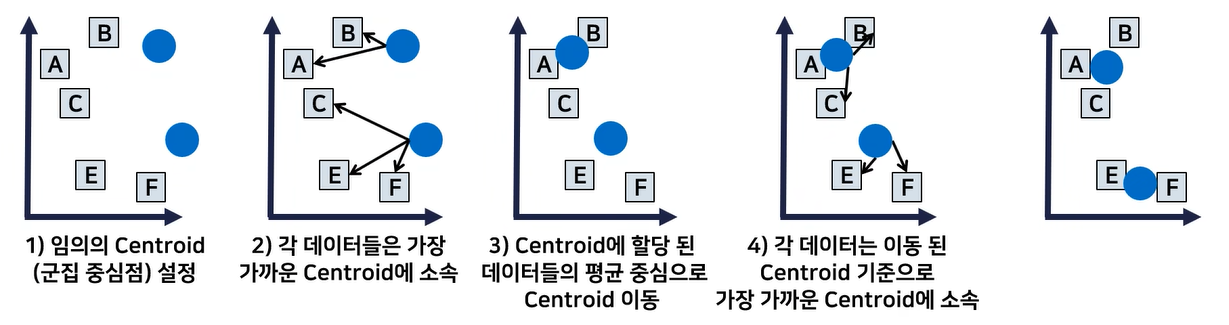

1. 임의의 Centroid (군집 중심점) 설정
2. 각 데이터들은 가장 가까운 Centroid 에 소속
3. Centroid에 할당 된 데이터들의 평균 중심으로 Centroid 이동
4. 각 데이터는 이동 된 Centroid 기준으로 가장 가까운 Centroid에 소속

In [54]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

- 문서를 tf-idf를 활용하여 수치화
    - tfidf 로 객체를 생성
    - tfidf.fit 을 통해 단어사전 구축
    - tfidf.transform 을 통해 구축한 단어사전 기반으로 데이터를 변경

In [ ]:
tfidf = TfidfVectorizer(
    tokenizer=lambda x: x ,# 토큰화를 수행하지 않도록 설정 
    token_pattern= None, # 기본 띄어쓰기를 기준으로 토큰화하나 수행하지 않도록 설정
    preprocessor= lambda x: x ,# 전처리를 수행하지 않도록 설정
    min_df = 10 # 최소 등장 빈도 설정 (전체 문서에서 10개 미만 문서에 등장한 단어는 제거 )                       
)

In [57]:
# 단어사전 구축
tfidf.fit(kakao_df['형태소 일반명사'])

TfidfVectorizer(min_df=10, preprocessor=<function <lambda> at 0x7a854a703b00>,
                token_pattern=None,
                tokenizer=<function <lambda> at 0x7a854a703600>)

In [60]:
# 단어사전 확인
vocab = tfidf.get_feature_names_out()

In [62]:
len(vocab)
print(vocab)

['ㄱ' 'ㄴ' 'ㄷ' ... '힘' '힙합' '힝']


In [63]:
X = tfidf.transform(kakao_df['형태소 일반명사'])

In [64]:
X.shape

(36000, 7217)

### K-means 활용하여 문서 군집화

- kmeans 에 대입하려면 수치형태로 만들어야함()

In [74]:
# 모델 객체 생성
k = 3
kmeans_model = KMeans(n_clusters=k,random_state=24)

In [75]:
kmeans_model.fit(X)

KMeans(n_clusters=3, random_state=24)

In [76]:
# 군집별 상위 가중치 단어 확인 (군집결과 해석을 위한 과정)
# 군집별 상위 가중치 단어 확인
print("\n=== Top terms per cluster===")
centroids = kmeans_model.cluster_centers_
topn = 10
for c in range(k):
    top_idx = centroids[c].argsort()[::-1][:topn]
    top_vocabs = [vocab[i] for i in top_idx]
    print(f"[cluster {c}] {", ".join(top_vocabs)}")


=== Top terms per cluster===
[cluster 0] 키, 사람, 집, 때, 게임, 말, 생각, 일, 돈, 친구
[cluster 1] 영화, 강아지, 키, 고양이, 동물, 반려, 집, 영화관, 마블, 사람
[cluster 2] 키, 때, 게임, 집, 사람, 친구, 말, 생각, 돈, 여행


In [79]:
def cluster(k):
    # k = 3
    kmeans_model = KMeans(n_clusters=k,random_state=24)
    kmeans_model.fit(X)
    print("\n=== Top terms per cluster===")
    centroids = kmeans_model.cluster_centers_
    topn = 10
    for c in range(k):
        top_idx = centroids[c].argsort()[::-1][:topn]
        top_vocabs = [vocab[i] for i in top_idx]
        print(f"[cluster {c}] {", ".join(top_vocabs)}")

In [97]:
cluster(30)


=== Top terms per cluster===
[cluster 0] 다이어트, 키, 운동, 살, 식단, 피부, 건강, 닭, 가슴살, 저녁
[cluster 1] 엄마, 아빠, 키, 집, 아들, 어머니, 말, 때, 가족, 부모
[cluster 2] 동물, 반려, 키, 햄스터, 벅수, 강아지, 고양이, 집, 사람, 용품
[cluster 3] 결혼, 키, 연애, 친구, 결혼식, 여자, 생각, 사람, 남자, 남편
[cluster 4] 집, 아파트, 키, 주택, 전세, 월세, 이사, 돈, 인테리어, 집값
[cluster 5] 겨울, 가을, 키, 여름, 눈, 날씨, 봄, 계절, 패딩, 옷
[cluster 6] 드라마, 키, 연기, 배우, 내용, 예능, 영화, 요즘, 시즌, 티비
[cluster 7] 강아지, 키, 산책, 동물, 집, 고양이, 반려, 사람, 개, 간식
[cluster 8] 키, 때, 사람, 친구, 말, 집, 돈, 생각, 요즘, 일
[cluster 9] 백신, 접종, 키, 부작용, 사람, 부스터, 샷, 나라, 확진, 마스크
[cluster 10] 게임, 키, 오징어, 롤, 때, 캐릭터, 사람, 요즘, 시간, 폰
[cluster 11] 차, 키, 버스, 운전, 지하철, 택시, 자동차, 대중교통, 면허, 시간
[cluster 12] 동생, 키, 누나, 오빠, 여동생, 형, 언니, 형제, 남동생, 외동
[cluster 13] 공부, 학원, 키, 영어, 자격증, 시험, 때, 토익, 학교, 외국어
[cluster 14] 배달, 키, 음식, 배민, 집, 치킨, 야식, 메뉴, 밥, 외식
[cluster 15] 날씨, 키, 가을, 비, 감기, 바람, 낮, 산책, 오늘, 옷
[cluster 16] 키, 커피, 밥, 점심, 치킨, 저녁, 아침, 맛, 집, 메뉴
[cluster 17] 낚시, 축구, 키, 선수, 야구, 경기, 배구, 팀, 스포츠, 운동
[cluster 18] 비, 키, 캠핑, 날씨, 우산, 태풍, 날, 때, 가을, 오늘
[cluster 19] 옷, 키, 쇼

### Topic Modeling
- 다양한 많은 문서에 숨겨진 의미구조인 주제(Topic)을 발견하는 알고리즘 
- 가장 대표적인 알고리즘: LDA (Latent Dirichlet Allocation)
- 대량의 문서 집합에서 문서안에 숨어 있는 '주제'를 자동으로 찾아내는 비지도학습 기법
- 비슷한 단어들이 자주 같이 등장하면 그 묶음은 하나의 주제로 간주


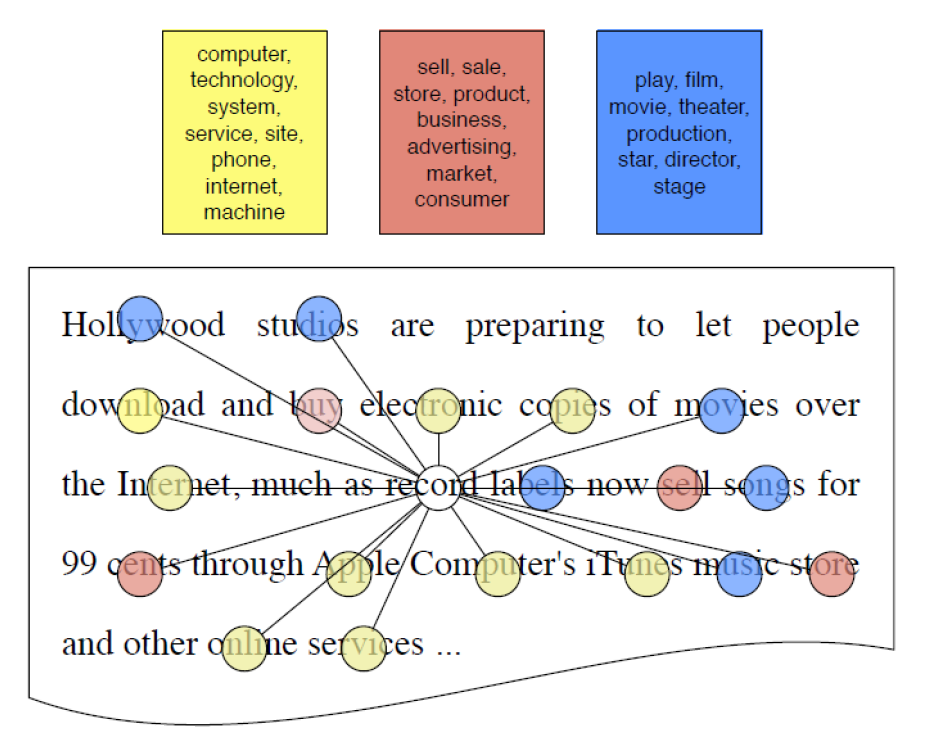

- BoW_CountVectorizer 를 활용한 LDA Topic Modeling
    - LDA는 확률모델이기 때문에 Count(빈도)가 중요함
    - 입력값이 단어의 개수여야하기 때문에 Countervectorizer를 사용하여 수치화 한다!

In [83]:
from sklearn.decomposition import LatentDirichletAllocation #LDA
from sklearn.feature_extraction.text import CountVectorizer #빈도수에 따라 수치화 해주는 도구

In [85]:
bow = CountVectorizer(
    tokenizer=lambda x: x ,# 토큰화를 수행하지 않도록 설정 
    token_pattern= None, # 기본 띄어쓰기를 기준으로 토큰화하나 수행하지 않도록 설정
    preprocessor= lambda x: x ,# 전처리를 수행하지 않도록 설정
    min_df = 10 # 최소 등장 빈도 설정 (전체 문서에서 10개 미만 문서에 등장한 단어는 제거 )                       
)

In [ ]:
# 단어사전 구축
bow.fit(kakao_df['형태소 일반명사'])

CountVectorizer(min_df=10, preprocessor=<function <lambda> at 0x7a854a790040>,
                token_pattern=None,
                tokenizer=<function <lambda> at 0x7a854a792660>)

In [90]:
print(bow.get_feature_names_out())
print(len(bow.get_feature_names_out()))

['ㄱ' 'ㄴ' 'ㄷ' ... '힘' '힙합' '힝']
7217


In [87]:
# 단어사전을 기반으로 문서 -> 수치화
bow.transform(kakao_df['형태소 일반명사'])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 804966 stored elements and shape (36000, 7217)>

In [91]:
# 모델 객체 생성 -0> 탐색하고자 하는 주제의 수 직접 설정
num_topcis = 3
lda_model = LatentDirichletAllocation(n_components=num_topcis,
                                      random_state=24,
                                      max_iter = 50, # 최대 반복횟수 설정
                                      learning_method='batch' # 학습의 효율성을 위한 배치단위 설정
)

In [98]:
# 모델 학습
lda_model.fit(X)

LatentDirichletAllocation(max_iter=50, n_components=3, random_state=24)

### 의사결정 지원
- 특정 주제가 언제 증가했는지?
- 고객의 불만의 주요 유형은 무엇인지
- 정치 이슈 흐름 분석
- 연구 트렌드 분석

In [99]:
# 토픽별 상위 단어 출력
def top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[::-1][:n_top_words]
        words = [feature_names[i] for i in top_idx]
        print(f"[Topic {topic_idx}] {' '.join(words)}")

print("=== Topics ===")
top_words(lda_model, vocab, 10)

=== Topics ===
[Topic 0] 키 게임 집 영화 여행 차 친구 결혼 때 사람
[Topic 1] 키 군대 운동 날씨 겨울 사람 건강 백신 나라 비
[Topic 2] 키 회사 공부 일 돈 때 머리 학원 밥 집


- Topic 모델링은 확률 중심. > "키" 라는 키워드는 세개의 토픽을 구분하는데 유의미하지 않음
- 토픽 해석 방법 :
1. 공통단어를 제거
2. 핵심 단어 묶음 파악
3. 이름 부여 (라벨링 작업)
4. 실제 문서와 검증
- 토픽은 "정확한 문장 주제"가 아니라! 단어 확률 분포 묶음이다!

> 토픽 : 하나의 문장 주제 X , 단어 확률 분포 O
> 단순히 패턴을 파악하는 과정이지, 주제를 설정하는 과정은 아니다!
